# Task 4.6 — Antibody Breadth: Fraction of Variants with HAI ≥ 40 (D28)

**4.6 Predict antibody breadth - all variants (D28)**
* Training Data: Demographics + Day 0 + Day 7 innate
* Assay: HAI / Measure: Percentage / Metric: Spearman correlation
* Full description: Percentage of variants with HAI >= 40 at Day 28

---

## Design notes

**y-values:** fraction (0.0–1.0) of measured HAI variants where raw titer ≥ 40 at D28. Since Spearman only cares about ranking, no inverse transform is needed for evaluation. Predictions are saved directly as fractions.

**Target construction:** for each participant, count `HAI_*_d28` columns ≥ log2(40) ≈ 5.32, divided by the number of measured variants. Participants with zero measured variants are excluded.

**Spearman correlation:** ranks predictions and truth; rewards monotonic agreement regardless of scale. Robust to outliers. Score: 1.0 = perfect, 0.0 = no signal, -1.0 = reversed.

**5-fold cross-validation:** each participant's prediction is made by a model that never saw them during training.

In [1]:
HAI_THRESHOLD = 40
TARGET_COL = 'TARGET_4_6'
AUTO_ML_MAX_RUNTIME_SECONDS = 600

In [2]:
PARQUET_PATH = '../merged_data/combined.parquet'
CHALLENGE_DATA_PATH = '../cleaned_data'
SUBMISSION_PATH = '../automl_submission'

In [3]:
import io
import warnings
from contextlib import redirect_stderr, redirect_stdout

import h2o
import numpy as np
import pandas as pd
from h2o.automl import H2OAutoML
from scipy.stats import spearmanr

In [4]:
challenge_participants = pd.read_csv(CHALLENGE_DATA_PATH + '/challenge_participants_cleaned.csv')
challenge_hai = pd.read_csv(CHALLENGE_DATA_PATH + '/challenge_hai_cleaned.csv')
challenge_data = challenge_hai.merge(challenge_participants, on='participant_id', how='inner')
print(f'Challenge shape: {challenge_data.shape}')

Challenge shape: (40, 23)


### Preprocessing — target construction and feature filtering

Target is computed from all `HAI_*_d28` columns (fraction ≥ 40 in raw titer space), then the full preprocessing pipeline filters out rows with no measured variants and columns that are too sparse or leaky to use.

In [5]:
df = pd.read_parquet(PARQUET_PATH)
print(f'Pre-filtered shape: {df.shape}')

Pre-filtered shape: (3757, 110063)


In [6]:
hai_d28_cols = [c for c in df.columns if c.startswith('HAI_') and c.endswith('_d28')]
threshold_log2 = np.log2(HAI_THRESHOLD)
above = (df[hai_d28_cols] >= threshold_log2).sum(axis=1)
measured = df[hai_d28_cols].notna().sum(axis=1)
df[TARGET_COL] = (above / measured).where(measured > 0)
print(f'Participants with valid target: {df[TARGET_COL].notna().sum()} / {len(df)}')

Participants with valid target: 3627 / 3757


In [7]:
df = df[df[TARGET_COL].notna()].reset_index(drop=True)
print(f'Filtered shape: {df.shape}')

Filtered shape: (3627, 110064)


In [8]:
all_null_cols = df.columns[df.isna().all()].tolist()
df = df.drop(columns=all_null_cols)
print(f'Dropped {len(all_null_cols)} all-null columns. New shape: {df.shape}')

Dropped 26510 all-null columns. New shape: (3627, 83554)


### Coerce HAI string columns to numeric

Some `HAI_*` titer columns are stored as strings (e.g. censored values like `<10` or stringified NaN). H2O treats those as categorical at training time but numeric at prediction time, which crashes `predict()`. We coerce all `HAI_*` string columns to numeric (non-numeric values become NaN). Genuine categoricals (demographics) are left alone.

In [9]:
str_cols = df.select_dtypes(include=['object', 'str']).columns.tolist()
print(f'String columns ({len(str_cols)}):', str_cols)

hai_str_cols = [c for c in str_cols if c.startswith('HAI_')]
for c in hai_str_cols:
    df[c] = pd.to_numeric(df[c], errors='coerce')
print(f'\nCoerced {len(hai_str_cols)} HAI string columns to numeric.')
print(f'Remaining string columns: {df.select_dtypes(include=["object", "str"]).columns.tolist()}')

# Apply same coercion to challenge data so type mismatch can't crash predict()
challenge_hai_str_cols = [c for c in challenge_data.select_dtypes(include=['object', 'str']).columns
                          if c.startswith('HAI_')]
for c in challenge_hai_str_cols:
    challenge_data[c] = pd.to_numeric(challenge_data[c], errors='coerce')
print(f'Coerced {len(challenge_hai_str_cols)} HAI string columns in challenge data.')

String columns (5): ['participant_id', 'PART_biological_sex', 'PART_race', 'PART_geolocation', 'PART_arm_name']

Coerced 0 HAI string columns to numeric.
Remaining string columns: ['participant_id', 'PART_biological_sex', 'PART_race', 'PART_geolocation', 'PART_arm_name']
Coerced 0 HAI string columns in challenge data.


### Drop constant features

Any column with only one unique value (numeric or categorical) carries no signal. Since we filtered to participants with a valid target, some categorical features may collapse to a single value here.

In [10]:
constant_cols = [c for c in df.columns
                 if c != TARGET_COL and df[c].nunique(dropna=True) <= 1]
df = df.drop(columns=constant_cols)
print(f'Dropped {len(constant_cols)} constant columns: {constant_cols}')
print(f'Shape: {df.shape}')

Dropped 63 constant columns: ['FLOW_Classical monocytes_d0', 'FLOW_Conventional DC_d0', 'FLOW_Neutrophils + Basophils_d0', 'FLOW_Classical monocytes_d7', 'FLOW_Conventional DC_d7', 'FLOW_Neutrophils + Basophils_d7', 'TRAN_ENSG00000204695_d7', 'TRAN_ENSG00000225012_d7', 'TRAN_ENSG00000225203_d7', 'TRAN_ENSG00000232309_d7', 'TRAN_ENSG00000249491_d7', 'TRAN_ENSG00000254787_d7', 'TRAN_ENSG00000286232_d0', 'TRAN_ENSG00000286391_d0', 'TRAN_ENSG00000288723_d0', 'TRAN_ENSG00000290669_d0', 'TRAN_ENSG00000290855_d0', 'TRAN_ENSG00000290909_d0', 'TRAN_ENSG00000293350_d0', 'TRAN_ENSG00000293876_d0', 'TRAN_ENSG00000294500_d0', 'TRAN_ENSG00000295176_d0', 'TRAN_ENSG00000295371_d0', 'TRAN_ENSG00000296345_d0', 'TRAN_ENSG00000298439_d0', 'TRAN_ENSG00000299622_d0', 'TRAN_ENSG00000300583_d0', 'TRAN_ENSG00000301618_d0', 'TRAN_ENSG00000302139_d0', 'TRAN_ENSG00000302927_d0', 'TRAN_ENSG00000305446_d0', 'TRAN_ENSG00000306888_d0', 'TRAN_ENSG00000307065_d0', 'TRAN_ENSG00000307366_d0', 'TRAN_ENSG00000307986_d0', '

### Drop sparse features

Drop columns missing in more than half the rows — they're too gappy for models to learn from and slow training enough that tree models time out (which is why previous runs produced only a GLM).

In [11]:
MISSING_THRESHOLD = 0.8

miss_frac = df.isna().mean()
high_miss = [c for c in miss_frac[miss_frac > MISSING_THRESHOLD].index if c != TARGET_COL]
df = df.drop(columns=high_miss)
print(f'Dropped {len(high_miss)} columns with >{MISSING_THRESHOLD:.0%} missing.')
print(f'Shape: {df.shape}')

Dropped 83421 columns with >80% missing.
Shape: (3627, 70)


### Drop other-task target columns

The challenge participants only have baseline data (demographics + d0 + d7) — d28 and d365 measurements don't exist for them yet (those are what we're being asked to predict). If we leave other `_d28` / `_d365` columns in the feature set, the model will learn to lean on them during training, but at predict time they'll all be NaN for the challenge data. Drop them all, keeping only `TARGET_COL`.

In [12]:
other_target_cols = [c for c in df.columns
                     if (c.endswith('_d28') and c != TARGET_COL) or c.endswith('_d365')]
df = df.drop(columns=other_target_cols)
print(f'Dropped {len(other_target_cols)} other-task target columns.')
print(f'Final shape: {df.shape}')

Dropped 37 other-task target columns.
Final shape: (3627, 33)


In [13]:
# Force float64 on all remaining HAI feature columns to prevent H2O from mistyping
# sparsely-populated columns as categorical, which crashes predict() on the challenge set.
hai_feature_cols = [c for c in df.columns if c.startswith('HAI_') and c != TARGET_COL]
for c in hai_feature_cols:
    df[c] = pd.to_numeric(df[c], errors='coerce')
    if c in challenge_data.columns:
        challenge_data[c] = pd.to_numeric(challenge_data[c], errors='coerce')
print(f'Forced float64 on {len(hai_feature_cols)} HAI feature columns in training and challenge data.')

Forced float64 on 26 HAI feature columns in training and challenge data.


In [14]:
print(f'Final shape: {df.shape}')
print(f'Target ({TARGET_COL}) stats:\n{df[TARGET_COL].describe()}')
print(f'\ndtype counts:\n{df.dtypes.value_counts()}')

Final shape: (3627, 33)
Target (TARGET_4_6) stats:
count    3627.000000
mean        0.628871
std         0.324547
min         0.000000
25%         0.400000
50%         0.666667
75%         0.933333
max         1.000000
Name: TARGET_4_6, dtype: float64

dtype counts:
float64    28
str         5
Name: count, dtype: int64


---
## AutoML Setup

In [15]:
warnings.filterwarnings("ignore", category=UserWarning, module="h2o")
h2o.init()

Checking whether there is an H2O instance running at http://localhost:54321..... not found.
Attempting to start a local H2O server...
; OpenJDK 64-Bit Server VM Temurin-25.0.2+10 (build 25.0.2+10-LTS, mixed mode, sharing)
  Starting server from C:\Users\User\anaconda3\envs\cmi-flu-prediction-challenge-capstone\Lib\site-packages\h2o\backend\bin\h2o.jar
  Ice root: C:\Users\User\AppData\Local\Temp\tmpmrc1_4yj
  JVM stdout: C:\Users\User\AppData\Local\Temp\tmpmrc1_4yj\h2o_User_started_from_python.out
  JVM stderr: C:\Users\User\AppData\Local\Temp\tmpmrc1_4yj\h2o_User_started_from_python.err
  Server is running at http://127.0.0.1:54321
Connecting to H2O server at http://127.0.0.1:54321 ... successful.


H2O_cluster_uptime:,01 secs
H2O_cluster_timezone:,America/Los_Angeles
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.10
H2O_cluster_version_age:,1 month and 27 days
H2O_cluster_name:,H2O_from_python_User_zkldmd
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,15.41 Gb
H2O_cluster_total_cores:,16
H2O_cluster_allowed_cores:,16
H2O_cluster_status:,"locked, healthy"


In [16]:
hai_col_types = {c: 'real' for c in hai_feature_cols}
data = h2o.H2OFrame(df, column_types=hai_col_types)
print(f'H2OFrame shape: {data.shape}')

Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
H2OFrame shape: (3627, 33)


---
## AutoML Training

In [17]:
y = TARGET_COL
x = [c for c in data.columns if c not in (y, 'participant_id')]
print(f'Training samples: {data.nrows}  |  Features: {len(x)}')

aml = H2OAutoML(max_models=10, seed=1, nfolds=5,
                keep_cross_validation_predictions=True,
                max_runtime_secs=AUTO_ML_MAX_RUNTIME_SECONDS)

_buf = io.StringIO()
with redirect_stdout(_buf), redirect_stderr(_buf):
    aml.train(x=x, y=y, training_frame=data)
print('Training complete.')

Training samples: 3627  |  Features: 31
Training complete.


In [18]:
lb_df = aml.leaderboard.as_data_frame(use_multi_thread=True)
lb_df

Export File progress: |██████████████████████████████████████████████████████████| (done) 100%


,model_id,rmse,mse,mae,rmsle,mean_residual_deviance
0,StackedEnsemble_AllModels_1_AutoML_1_20260509_...,0.192522,0.037065,0.137503,0.128603,0.037065
1,GBM_2_AutoML_1_20260509_162046,0.193721,0.037528,0.138677,0.129133,0.037528
2,StackedEnsemble_BestOfFamily_1_AutoML_1_202605...,0.193911,0.037602,0.138491,0.129431,0.037602
3,GBM_4_AutoML_1_20260509_162046,0.194450,0.037811,0.138938,0.129572,0.037811
4,GBM_3_AutoML_1_20260509_162046,0.195676,0.038289,0.139466,0.130454,0.038289
5,GBM_5_AutoML_1_20260509_162046,0.195898,0.038376,0.140848,0.130833,0.038376
6,GBM_grid_1_AutoML_1_20260509_162046_model_1,0.196027,0.038426,0.141202,0.130941,0.038426
7,GBM_1_AutoML_1_20260509_162046,0.196690,0.038687,0.142818,0.131229,0.038687
8,XRT_1_AutoML_1_20260509_162046,0.200290,0.040116,0.148456,0.133148,0.040116
9,DRF_1_AutoML_1_20260509_162046,0.200437,0.040175,0.141603,0.133180,0.040175


In [19]:
# Grab the best base model (skipping troublesome stacked ensembles)
best_base_model_id = lb_df[~lb_df['model_id'].str.contains('StackedEnsemble')]['model_id'].iloc[0]
top_model = h2o.get_model(best_base_model_id)

# Now we can safely get CV predictions
cv_preds = top_model.cross_validation_holdout_predictions().as_data_frame(use_multi_thread=True)['predict']
actuals = data[y].as_data_frame(use_multi_thread=True)[y]

rho, pval = spearmanr(actuals, cv_preds)
print(f'Task 4.6 — Spearman (Best Base Model 5-fold CV): {rho:.3f}  (p={pval:.4f})')

Export File progress: |██████████████████████████████████████████████████████████| (done) 100%
Export File progress: |██████████████████████████████████████████████████████████| (done) 100%
Task 4.6 — Spearman (Best Base Model 5-fold CV): 0.768  (p=0.0000)


Leader model: GBM_2_AutoML_1_20260509_162046


,variable,relative_importance,scaled_importance,percentage
0,PART_geolocation,520.467041,1.000000,0.376130
1,HAI_H1N1 A/California/7/2009_d0,146.169937,0.280844,0.105634
2,PART_age,118.196434,0.227097,0.085418
3,HAI_Vic B/Brisbane/60/2008_d0,85.119919,0.163545,0.061514
4,HAI_H3N2 A/Singapore/INFIMH-160019/2016_d0,64.769928,0.124446,0.046808
5,HAI_H3N2 A/South Australia/34/2019_d0,54.817970,0.105325,0.039616
6,HAI_H1N1 A/Brisbane/59/2007_d0,53.597218,0.102979,0.038734
7,HAI_Yam B/Florida/4/2006_d0,51.070221,0.098124,0.036907
8,HAI_H3N2 A/Perth/16/2009_d0,38.295540,0.073579,0.027675
9,HAI_H3N2 A/Victoria/361/2011_d0,26.013950,0.049982,0.018800


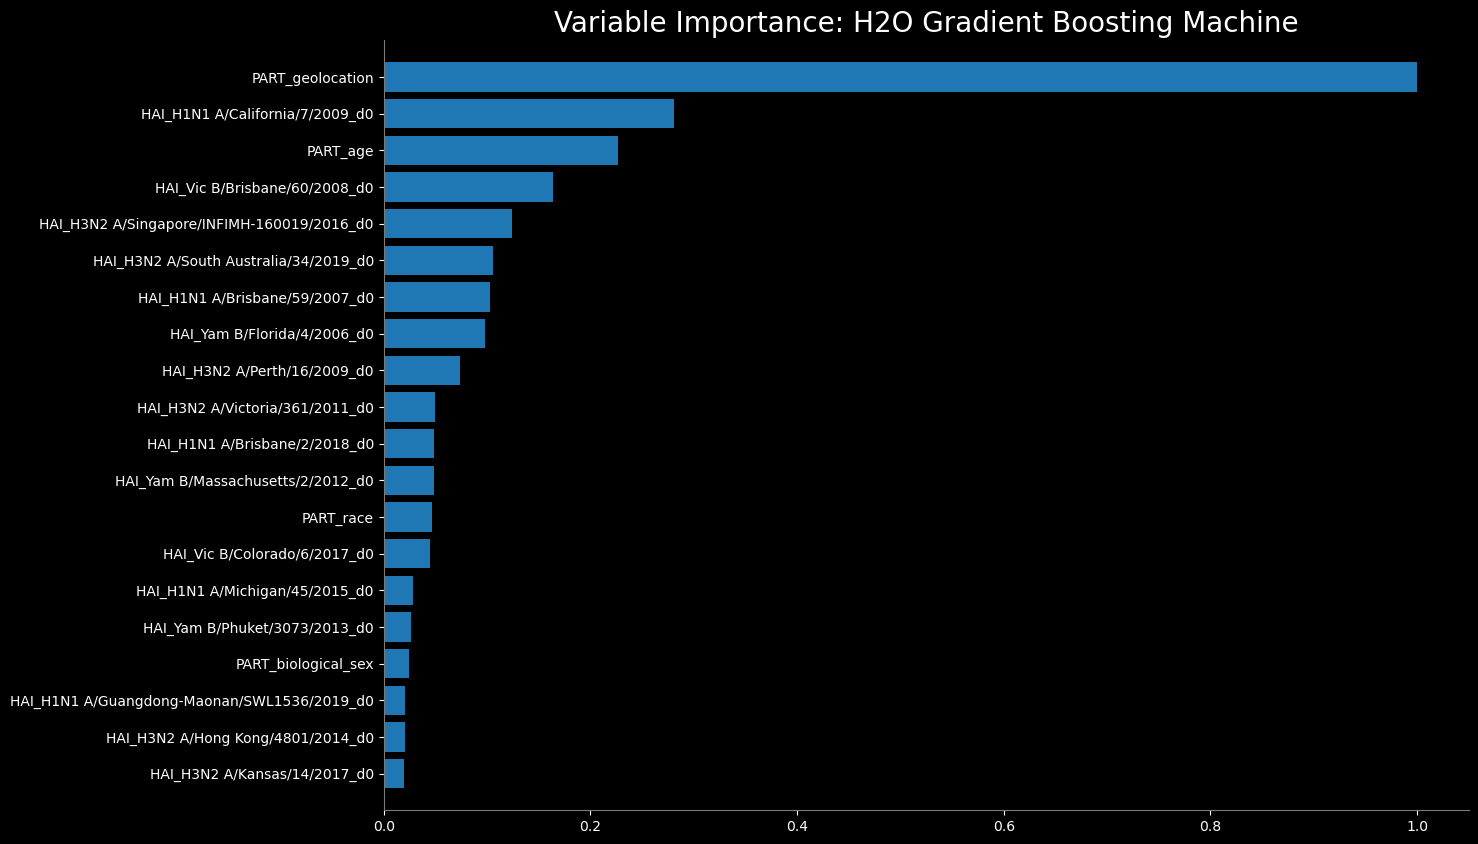

<Figure size 640x480 with 0 Axes>

In [20]:
print(f'Leader model: {top_model.model_id}')
varimp = top_model.varimp(use_pandas=True)
display(varimp.head(20))
top_model.varimp_plot(num_of_features=20)

In [21]:
challenge_col_types = {c: 'real' for c in hai_feature_cols if c in challenge_data.columns}
challenge_hf = h2o.H2OFrame(challenge_data, column_types=challenge_col_types)
y_pred = top_model.predict(challenge_hf).as_data_frame(use_multi_thread=True)['predict']

results = pd.DataFrame({
    'Participant_ID': challenge_data['participant_id'].values,
    'Task_4.6': y_pred,  # fraction — no inverse transform
})
results.to_csv(f'{SUBMISSION_PATH}/task_4_6.csv', index=False)
results

Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
gbm prediction progress: |███████████████████████████████████████████████████████| (done) 100%
Export File progress: |██████████████████████████████████████████████████████████| (done) 100%


,Participant_ID,Task_4.6
0,2024_UGA.ID_077,0.401698
1,2024_UGA.ID_086,0.659406
2,2024_UGA.ID_128,0.840835
3,2024_UGA.ID_170,0.528421
4,2024_UGA.ID_179,0.628066
5,2024_UGA.ID_215,0.682861
6,2024_UGA.ID_219,0.707267
7,2024_UGA.ID_275,0.387646
8,2024_UGA.ID_295,0.467207
9,2024_UGA.ID_296,0.343760


In [22]:
model_path = h2o.save_model(model=top_model, path='.', filename='model_4.6', force=True)
print(f'Model saved to: {model_path}')

Model saved to: C:\Users\User\repos\cmi-flu-prediction-challenge-capstone\automl_models\model_4.6


In [23]:
h2o.cluster().shutdown()

H2O session _sid_8cd2 closed.


---
## Conclusion

- **Leader model:** GBM_2 (Gradient Boosting Machine)
- **CV Spearman:** 0.768 (p < 0.0001)
- **Training samples:** 3,627 | **Features:** 31
- **Model saved:** `automl_models/model_4.6`

**Target:** fraction of measured HAI variants where raw titer ≥ 40 at D28. Predictions are saved directly as fractions (no `exp2`). All 40 challenge predictions fall in [0.12, 0.94] — no negative values unlike the baseline linear model.

**Feature set:** 26 HAI d0 columns (baseline titers across strains) + 5 demographics, after dropping columns >80% missing and all d28/d365 leakage columns.

**Imputation note:** No manual imputation is applied. H2O's tree models (GBM, XRT, DRF) handle `NaN` natively at each split during training and prediction, including inside CV folds — eliminating any leakage that would arise from pre-computing medians on the full training set.

Submission saved to `automl_submission/task_4_6.csv`.

To reload the model: `h2o.load_model('automl_models/model_4.6')`